In [ ]:
import matplotlib.pyplot as plt
import numpy as np


class ToyBandit:
    """
    K-armed bandit with fixed (unknown) reward means in [0, 1].
    Represents the envrionment for online hyper-parameter tuning.
    """
    def __init__(self, probs, seed=0):
        self.probs = np.array(probs, dtype=float)
        self.K = len(probs)
        self.rng = np.random.default_rng(seed)

    def pull(self, arm: int) -> float:
        # Bernoulli reward in {0,1} ⊂ [0,1]
        # sample from arm distribution
        return float(self.rng.random() < self.probs[arm])

    @property
    def best_mean(self):
        return float(np.max(self.probs))



In [ ]:
import matplotlib.pyplot as plt
import numpy as np


class ToyBandit:
    """
    K-armed bandit with fixed (unknown) reward means in [0, 1].
    Represents the envrionment for online hyper-parameter tuning.
    """
    def __init__(self, probs, seed=0):
        self.probs = np.array(probs, dtype=float)
        self.K = len(probs)
        self.rng = np.random.default_rng(seed)

    def pull(self, arm: int) -> float:
        # Bernoulli reward in {0,1} ⊂ [0,1]
        # sample from arm distribution
        return float(self.rng.random() < self.probs[arm])

    @property
    def best_mean(self):
        return float(np.max(self.probs))



In [ ]:

class ToyUCBEvaluator:
    """
    Toy implementation of UCB MAB.
    Mirrors the structure of the real UCB implementation """
    def __init__(self, bandit: ToyBandit, alpha: float = 1.0, seed=0):
        self.bandit = bandit
        self.alpha = float(alpha) # alpha controls exploration vs exploitation
        self.rng = np.random.default_rng(seed)

        self.K = bandit.K
        self.t = 0
        self.counts = np.zeros(self.K, dtype=np.int64)
        self.values = np.zeros(self.K, dtype=np.float64)

    def _select_arm(self) -> int:
        """
        UCB arm selection.
        """
        # Pull each arm once
        for a in range(self.K):
            if self.counts[a] == 0:
                return a

        t = self.t + 1
        bonus = self.alpha * np.sqrt(np.log(t) / self.counts)
        ucb = self.values + bonus

        return int(np.argmax(ucb))

    def _update_arm(self, arm: int, reward: float) -> None:
        """
        Incremental mean update.
        """

        # update expected reward for that arm
        self.counts[arm] += 1
        n = self.counts[arm]
        self.values[arm] += (reward - self.values[arm]) / n # incremental mean update

    def evaluate(self, trials: int = 5000):
        """
        Runs the bandit loop and returns learning curves.
        """

        rewards = np.zeros(trials)
        avg_rewards = np.zeros(trials)
        regrets = np.zeros(trials)

        mu_star = self.bandit.best_mean

        for t in range(trials):

            arm = self._select_arm() # select an arm
            reward = self.bandit.pull(arm) # compute reward for that arm

            self._update_arm(arm, reward) # update expected reward for that arm
            self.t += 1

            rewards[t] = reward
            avg_rewards[t] = rewards[: t + 1].mean()
            regrets[t] = (mu_star - self.bandit.probs[arm]) + (
                regrets[t - 1] if t > 0 else 0.0
            )

        return rewards, avg_rewards, regrets




True means: [0.05, 0.1, 0.08, 0.2, 0.18]
Estimated means: [0.0343 0.0836 0.0714 0.2082 0.1873]
Pull counts: [ 175  287  252 3535 1751]


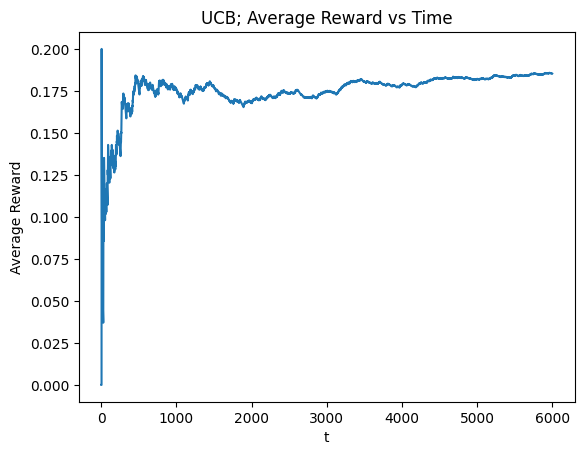

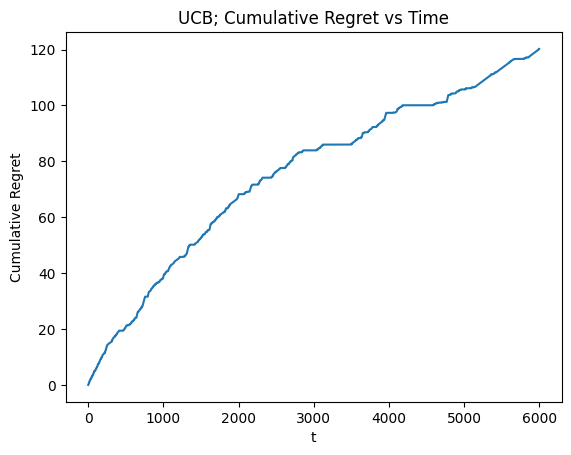

In [ ]:

if __name__ == "__main__":
    # true arm means
    probs = [0.05, 0.10, 0.08, 0.20, 0.18]

    bandit = ToyBandit(probs, seed=42)
    evaluator = ToyUCBEvaluator(bandit, alpha=1.0, seed=0)

    rewards, avg_rewards, regrets = evaluator.evaluate(trials=6000)

    print("True means:", probs)
    print("Estimated means:", np.round(evaluator.values, 4))
    print("Pull counts:", evaluator.counts)

    # plot
    plt.figure()
    plt.plot(avg_rewards)
    plt.xlabel("t")
    plt.ylabel("Average Reward")
    plt.title("UCB; Average Reward vs Time")
    plt.show()

    plt.figure()
    plt.plot(regrets)
    plt.xlabel("t")
    plt.ylabel("Cumulative Regret")
    plt.title("UCB; Cumulative Regret vs Time")
    plt.show()
